This is part 1 of a tutorial series. We recommend following them in order, starting with [Part 0: Welcome to `musica`](0.%20Welcome%20to%20MUSICA.ipynb).

# TS1 Box Model

This tutorial walks through a coupled `tuv-x` / `micm` box model simulation using the TS1 (Tropospheric Standard 1) atmospheric chemistry mechanism.

The simulation runs over a vertical column of 9 altitude grid cells (1–10 km) for a real geographic location (Boulder, CO) beginning at 6:30 AM local time. At each time step, TUV-x recomputes photolysis rate constants based on the current solar zenith angle, `ussa1976` provides temperature and pressure from the US Standard Atmosphere, and `micm` integrates the chemical kinetics forward in time.

Before working through this tutorial, it is recommended to complete:
- [Tutorial 1: Multiple Grid Cells](1.%20multiple_grid_cells.ipynb) — covers MICM state setup and multi-cell solving
- [Tutorial 8: TUV-x Standard Configurations](8.%20tuv-x_standard_configurations.ipynb) — covers computing photolysis rate constants with TUV-x
- [Tutorial 10: Chapman Cycle](10.%20chapman.ipynb) — covers coupling TUV-x and MICM with diurnal photolysis updates

## 1. Imports

In [2]:
import json
from datetime import datetime, time, timedelta
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
import ussa1976
import xarray as xr

import musica
from musica.mechanism_configuration import Parser
from musica.micm.solver_result import SolverState
from musica.tuvx import vTS1
from musica.utils import find_config_path

SECONDS_PER_HOUR = 3600

## 2. Location and Simulation Time

As in the [Chapman tutorial](10.%20chapman.ipynb), we simulate over Boulder, CO starting at 6:30 AM local time. All times are tracked as timezone-aware `datetime` objects in UTC.

In [3]:
boulder = (40.01879858223568, -105.27492413846649)  # (latitude, longitude)
boulder_tz = ZoneInfo("America/Denver")

today_local = datetime.now(boulder_tz).date()
sim_local  = datetime.combine(today_local, time(6, 30), tzinfo=boulder_tz)
sim_time    = sim_local.astimezone(ZoneInfo("UTC"))

print(f"Simulation start (UTC):   {sim_time}")
print(f"Simulation start (local): {sim_time.astimezone(boulder_tz)}")

Simulation start (UTC):   2026-04-03 12:30:00+00:00
Simulation start (local): 2026-04-03 06:30:00-06:00


## 3. Load `tuv-x` and Define a Helper to Compute Photolysis Rates

We load the vTS1 `tuv-x` calculator once and keep it alive for the duration of the simulation. The alias table in the TS1 config file maps TUV-x reaction labels to the `USER.j*` parameter names expected by the MICM mechanism.

We define a helper function that:
1. Uses `pvlib` to compute the solar zenith angle (SZA) at Boulder for a given time.
2. Runs TUV-x with that SZA to get photolysis rate constants at every altitude.
3. Maps the TUV-x labels to `USER.j*` names using the alias table.

In [4]:
tuvx = vTS1.get_tuvx_calculator()

tuv_path = find_config_path("tuvx", "ts1_tsmlt.json")
with open(tuv_path, 'r') as f:
    data = json.load(f)
alias_mappings = data.get('__CAM options', {}).get('aliasing', {}).get('pairs', {})

print(f"Loaded {len(alias_mappings)} photolysis rate alias mappings")

Loaded 122 photolysis rate alias mappings


Next, let's create the convenience function. The `tuv-x` altitude grid starts at 0 km. We skip the 0 km level (index 0) because it represents the surface boundary. We use grid edges at indices 1–9, which correspond to 1–10 km.

In [5]:
def get_tuv_rates(utc_time, num_grid_cells, start=1):
    """Return photolysis rate constants for `num_grid_cells` altitude cells starting at index `start`."""
    lat, lon = boulder
    solpos = pvlib.solarposition.get_solarposition(time=utc_time, latitude=lat, longitude=lon)
    sza_deg = solpos['zenith'].item()

    tuv_rates = tuvx.run(sza=np.deg2rad(sza_deg), earth_sun_distance=1.0)
    end = start + num_grid_cells

    photolysis_rate_constants = {}
    for mapping in alias_mappings:
        label    = mapping['to']
        scale    = mapping.get("scale by", 1)
        tuv_label = mapping['from']
        rate = tuv_rates.sel(reaction=tuv_label).photolysis_rate_constants.values * scale
        photolysis_rate_constants[f'USER.{label}'] = rate[start:end]

    return photolysis_rate_constants, tuv_rates

## 4. Altitude Grid, Atmospheric Conditions, and Solver Setup

We use TUV-x altitude grid cells 1–9 (approximately 1–10 km). Temperature and pressure at those altitudes come from the US Standard Atmosphere 1976 model. We compute the initial photolysis rates for the simulation start time.

In [6]:
start = 1
num_grid_cells = 9

# Compute initial photolysis rates and grab the altitude edges for our grid cells
photolysis_rate_constants, tuv_rates = get_tuv_rates(sim_time, num_grid_cells, start)
vertical_edges = tuv_rates.vertical_edge[start:start + num_grid_cells].data

print(f"Altitude range: {vertical_edges.min():.1f} – {vertical_edges.max():.1f} km")

# US Standard Atmosphere T and P at those altitudes (km -> m)
atm         = ussa1976.compute(z=vertical_edges * 1000, variables=["t", "p"])
temperature = atm['t'].values
pressure    = atm['p'].values

print(f"Temperature range: {temperature.min():.1f} – {temperature.max():.1f} K")
print(f"Pressure range:    {pressure.min():.1f} – {pressure.max():.1f} Pa")

# Load mechanism and create solver
parser = Parser()
mechanism = parser.parse(find_config_path("v1", "ts1", "ts1.json"))

solver = musica.MICM(
    mechanism=mechanism,
    solver_type=musica.SolverType.rosenbrock_standard_order
)

state = solver.create_state(num_grid_cells)

print(f"Solver created with {num_grid_cells} grid cells")
print(f"Mechanism has {len(list(state.get_species_ordering()))} species")

Altitude range: 1.0 – 9.0 km
Temperature range: 229.7 – 281.7 K
Pressure range:    30800.7 – 89876.3 Pa
Solver created with 9 grid cells
Mechanism has 209 species


## 5. Load Initial Conditions

The initial conditions CSV contains parameters for all grid cells. Each row has a parameter name and one or two values, following this convention:

| Prefix | value1 | value2 |
|--------|--------|--------|
| `CONC` | Initial concentration (mol m⁻³) | — |
| `ENV`  | Temperature (K) or Pressure (Pa) | — |
| `USER` | User-defined parameter value | — |
| `SURF` | Effective radius (m) | Particle number concentration (# m⁻³) |

We split the file into these four groups and process each separately.

In [7]:
conditions = pd.read_csv(
    find_config_path("v1", "ts1", "initial_conditions.csv"),
    sep=',',
    names=['parameter', 'value1', 'value2'],
    dtype={'parameter': str, 'value1': float, 'value2': float}
)

surface_reactions       = conditions[conditions['parameter'].str.contains('SURF')]
initial_concentrations  = conditions[conditions['parameter'].str.contains('CONC')].copy()
environmental_conditions = conditions[conditions['parameter'].str.contains('ENV')]
user_defined_conditions = conditions[conditions['parameter'].str.contains('USER')]

# Strip the 'CONC.' prefix so names match the species ordering expected by the solver
initial_concentrations.loc[:, 'parameter'] = (
    initial_concentrations['parameter'].str.replace('CONC.', '', regex=False)
)

assert (
    len(surface_reactions) + len(initial_concentrations) +
    len(environmental_conditions) + len(user_defined_conditions)
) == len(conditions)

print(f"Loaded {len(initial_concentrations)} species, {len(user_defined_conditions)} user-defined params, "
      f"{len(surface_reactions)} surface reactions")

Loaded 208 species, 140 user-defined params, 13 surface reactions


## 6. Set State Conditions

We populate the solver state with:
- **Concentrations** from the initial conditions CSV, broadcast to all grid cells.
- **Temperature and pressure** from the US Standard Atmosphere (`ussa1976`), evaluated at the `tuv-x` altitude grid edges for our 9 cells.
- **User-defined rate parameters** from the CSV, overwritten with the TUV-x photolysis rates where applicable.
- **Surface reaction parameters** (effective radius and particle number concentration) also from the CSV.

In [8]:
# Build concentration dict — same value broadcast to every grid cell
concentration_dict = {
    row['parameter']: [row['value1']] * num_grid_cells
    for _, row in initial_concentrations.iterrows()
}

# Build user-defined rate parameters dict
user_defined_dict = {
    row['parameter']: [row['value1']] * num_grid_cells
    for _, row in user_defined_conditions.iterrows()
}

# Surface reactions require two parameters: effective radius and particle number concentration
for _, row in surface_reactions.iterrows():
    user_defined_dict[f"{row['parameter']}.effective radius [m]"] = [row['value1']] * num_grid_cells
    user_defined_dict[f"{row['parameter']}.particle number concentration [# m-3]"] = [row['value2']] * num_grid_cells

# Overwrite scalar USER.j* values with the per-altitude TUV-x photolysis rates
found_rates  = sorted(photolysis_rate_constants.keys())
needed_rates = sorted([k for k in state.get_user_defined_rate_parameters() if 'USER.j' in k])
missing_rates = set(needed_rates) - set(found_rates)
if missing_rates:
    print(f"Missing photolysis rates (will remain at CSV values): {missing_rates}")
user_defined_dict.update(photolysis_rate_constants)

# Apply everything to the state
state.set_conditions(temperature, pressure)
state.set_concentrations(concentration_dict)
state.set_user_defined_rate_parameters(user_defined_dict)

print("State initialised.")
print(f"Temperature range: {temperature.min():.1f} – {temperature.max():.1f} K")
print(f"Pressure range:    {pressure.min():.0f} – {pressure.max():.0f} Pa")

Missing photolysis rates (will remain at CSV values): {'USER.jno'}
State initialised.
Temperature range: 229.7 – 281.7 K
Pressure range:    30801 – 89876 Pa


## 7. Run the Simulation

We integrate forward for 1/10 of a day (~2.4 hours) in 30-second steps. At the end of each step we:
- Advance the simulation clock by the step duration.
- Recompute the solar zenith angle for the new time using `pvlib`.
- Update the photolysis rates on the state before the next step.

This means the photolysis rates change with the diurnal cycle throughout the simulation.

In [9]:
sim_times          = [sim_time]
concentrations     = [state.get_concentrations()]
photo_rate_history = [{k: v.copy() for k, v in state.get_user_defined_rate_parameters().items()}]

time_step         = 30                        # seconds per output step
simulation_length = 0.1 * 24 * SECONDS_PER_HOUR  # 1/10 of a day in seconds
current_time      = 0
last_printed_percent = -5

while current_time < simulation_length:
    # Inner loop: accumulate solver sub-steps until a full time_step is consumed
    elapsed = 0
    while elapsed < time_step:
        remaining = time_step - elapsed
        result = solver.solve(state, remaining)
        elapsed      += result.stats.final_time
        current_time += result.stats.final_time
        if result.state != SolverState.Converged:
            print(f"  Solver state: {result.state} at t={current_time:.1f} s")

    # Advance the wall-clock time and update photolysis rates for the new position
    sim_time += timedelta(seconds=time_step)
    photolysis_rate_constants, _ = get_tuv_rates(sim_time, num_grid_cells, start)

    user_defined_dict = state.get_user_defined_rate_parameters()
    for key in photolysis_rate_constants:
        user_defined_dict[key] = photolysis_rate_constants[key]
    state.set_user_defined_rate_parameters(user_defined_dict)

    sim_times.append(sim_time)
    concentrations.append(state.get_concentrations())
    photo_rate_history.append({k: v.copy() for k, v in state.get_user_defined_rate_parameters().items()})

    current_percent = (current_time / simulation_length) * 100
    rounded = int(current_percent // 5) * 5
    if rounded > last_printed_percent:
        last_printed_percent = rounded
        local_str = sim_time.astimezone(boulder_tz).strftime('%H:%M %Z')
        print(f"Progress: {last_printed_percent}%  (sim time: {local_str})")

print("Simulation complete.")

Progress: 0%  (sim time: 06:30 MDT)
Progress: 5%  (sim time: 06:37 MDT)
Progress: 10%  (sim time: 06:44 MDT)
Progress: 15%  (sim time: 06:52 MDT)
Progress: 20%  (sim time: 06:59 MDT)
Progress: 25%  (sim time: 07:06 MDT)
Progress: 30%  (sim time: 07:13 MDT)
Progress: 35%  (sim time: 07:20 MDT)
Progress: 40%  (sim time: 07:28 MDT)
Progress: 45%  (sim time: 07:35 MDT)
Progress: 50%  (sim time: 07:42 MDT)
Progress: 55%  (sim time: 07:49 MDT)
Progress: 60%  (sim time: 07:56 MDT)
Progress: 65%  (sim time: 08:04 MDT)
Progress: 70%  (sim time: 08:11 MDT)
Progress: 75%  (sim time: 08:18 MDT)
Progress: 80%  (sim time: 08:25 MDT)
Progress: 85%  (sim time: 08:32 MDT)
Progress: 90%  (sim time: 08:40 MDT)
Progress: 95%  (sim time: 08:47 MDT)
Progress: 100%  (sim time: 08:54 MDT)
Simulation complete.


## 8. Collect Results into an xarray Dataset

We organise the simulation output into an `xr.Dataset` with dimensions `time` and `height`. Time is stored as actual `datetime64` timestamps. Photolysis rates are recorded at every time step so we can see how they vary with the diurnal cycle.

In [10]:
final_conditions = state.get_conditions()

data_vars = {
    "temperature": (["height"], final_conditions["temperature"], {"units": "K"}),
    "pressure":    (["height"], final_conditions["pressure"],    {"units": "Pa"}),
    "air_density": (["height"], final_conditions["air_density"], {"units": "mol m-3"}),
}

# Photolysis rates over time
photo_names  = list(photo_rate_history[0].keys())
photo_values = [[params[name] for name in photo_names] for params in photo_rate_history]
data_vars["photolysis_rates"] = (
    ["time", "photolysis_rate_names", "height"],
    photo_values,
    {"units": "s-1"}
)

# Species concentrations (time x height)
species_ordering = state.get_species_ordering()
for species in species_ordering:
    data_vars[species] = (
        ["time", "height"],
        np.array([c[species] for c in concentrations], dtype=np.float64),
        {"units": "mol m-3"}
    )

ds = xr.Dataset(
    data_vars,
    coords={
        "time":                  np.array(sim_times, dtype="datetime64[s]"),
        "height":                vertical_edges,
        "photolysis_rate_names": np.array(photo_names, dtype="S"),
    }
)

print(ds)

<xarray.Dataset> Size: 8MB
Dimensions:                (height: 9, time: 290, photolysis_rate_names: 168)
Coordinates:
  * height                 (height) float64 72B 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0
  * time                   (time) datetime64[s] 2kB 2026-04-03T12:30:00 ... 2...
  * photolysis_rate_names  (photolysis_rate_names) |S59 10kB b'SURF.usr_HO2_a...
Data variables: (12/213)
    temperature            (height) float64 72B 281.7 275.2 ... 236.2 229.7
    pressure               (height) float64 72B 8.988e+04 7.95e+04 ... 3.08e+04
    air_density            (height) float64 72B 38.38 34.75 ... 18.15 16.13
    photolysis_rates       (time, photolysis_rate_names, height) float64 4MB ...
    MALO2                  (time, height) float64 21kB 1.07e-13 ... 7.031e-14
    NC4CHO                 (time, height) float64 21kB 3.67e-11 ... 2.877e-13
    ...                     ...
    CL                     (time, height) float64 21kB 1.07e-15 ... 4.174e-16
    NO3                    (time, he

/var/folders/r1/2y11n4k961s63xm2vt0sd5ww0018dl/T/ipykernel_75937/1807138315.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  "time":                  np.array(sim_times, dtype="datetime64[s]"),


## 9. Plot Results

We plot the time evolution of four representative species — BEPOMUC, C6H5OOH, BR, and CL — for every grid cell. Each line corresponds to one altitude.

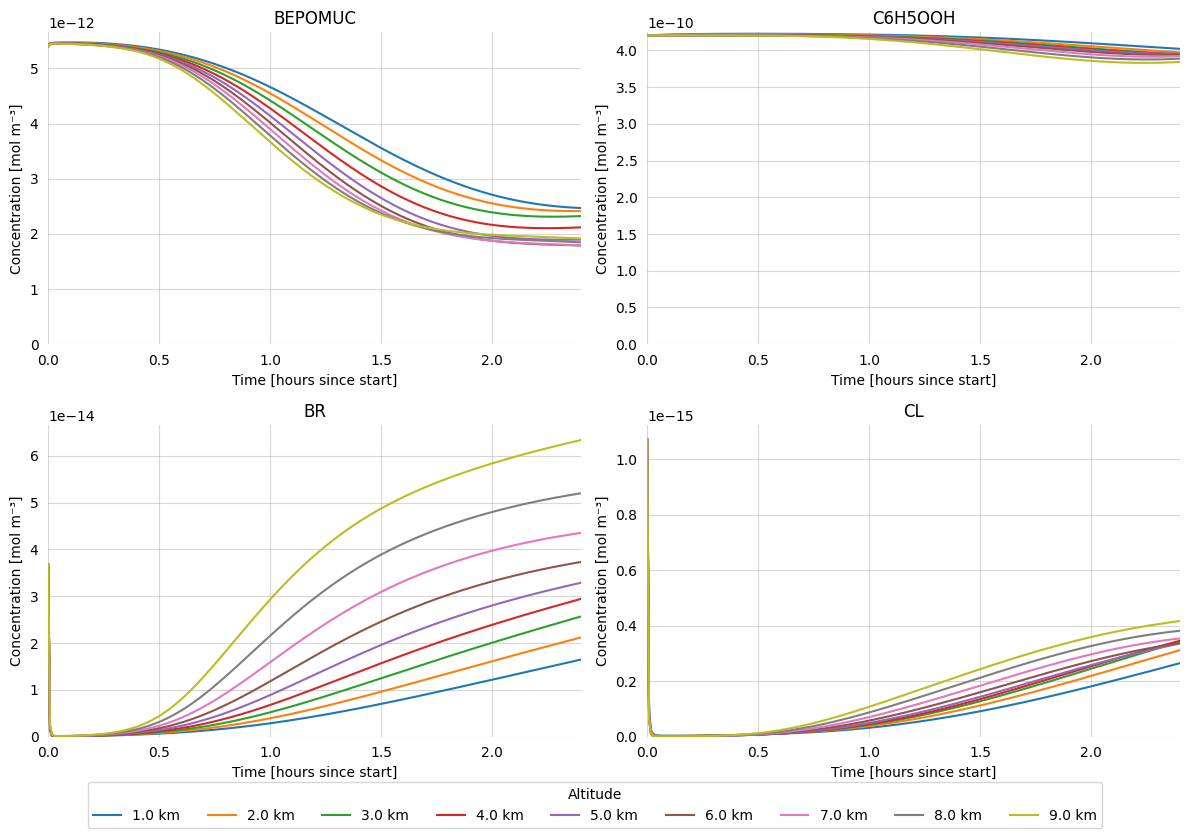

In [11]:
elapsed_hours = (ds['time'] - ds['time'].isel(time=0)) / np.timedelta64(1, 'h')
species_to_plot = ['BEPOMUC', 'C6H5OOH', 'BR', 'CL']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, species in zip(axes.flat, species_to_plot):
    for cell in range(num_grid_cells):
        ax.plot(elapsed_hours, ds[species].isel(height=cell), label=f"{vertical_edges[cell]:.1f} km")
    ax.set_title(species)
    ax.set_xlabel('Time [hours since start]')
    ax.set_ylabel('Concentration [mol m⁻³]')
    ax.set_xlim(0, simulation_length / SECONDS_PER_HOUR)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.5)
    ax.spines[:].set_visible(False)
    ax.tick_params(width=0)

# Add a shared legend outside the last axis
handles, labels = axes.flat[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Altitude', loc='lower center', ncol=num_grid_cells, bbox_to_anchor=(0.5, -0.05))

fig.tight_layout()
plt.show()